## Setup & Custom Visualization Configuration

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress non-critical warnings
warnings.filterwarnings('ignore')

# Set visual aesthetic standards
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

SEED = 42
np.random.seed(SEED)

print("Environment setup and plot formatting configured.")

Environment setup and plot formatting configured.


## Data Ingestion & Dataset Schema Profiling

In [3]:
train_df = pd.read_csv("/content/train.csv")
test_df = pd.read_csv("/content/test.csv")

print(f"Train Dimensions: {train_df.shape} (Expected 12,000 rows, 35 columns)")
print(f"Test Dimensions:  {test_df.shape} (Expected 8,000 rows, 34 columns)")
print(f"Train Memory Usage: {train_df.memory_usage().sum() / 1024**2:.2f} MB\n")

# Define schema classifications
ID_COL = "customer_id"
TARGET_COL = "churn"

NUMERICAL_COLS = [
    "age", "tenure_months", "number_of_services", "data_usage_gb",
    "streaming_hours_monthly", "device_age_months", "app_sessions_weekly",
    "average_session_minutes", "payment_delay_days", "late_payment_count",
    "discount_percentage", "monthly_charge", "network_complaints",
    "support_calls_90d", "satisfaction_score", "referral_count", "lifetime_spend"
]

CATEGORICAL_COLS = [
    "customer_segment", "region", "acquisition_channel", "contract_type",
    "plan_tier", "internet_type", "device_type", "support_plan",
    "payment_method", "promotion_type", "streaming_service",
    "priority_support", "autopay", "paperless_billing", "family_plan",
    "international_plan"
]


Train Dimensions: (12000, 35) (Expected 12,000 rows, 35 columns)
Test Dimensions:  (8000, 34) (Expected 8,000 rows, 34 columns)
Train Memory Usage: 3.20 MB



In [6]:
# Quick statistical summary of numerical attributes
display(train_df[NUMERICAL_COLS].describe().T[['mean', 'std', 'min','25%', '50%','75%', 'max']])


,mean,std,min,25%,50%,75%,max
age,42.541194,15.371535,18.00,30.0000,43.000,54.00,88.00
tenure_months,19.950868,16.718891,0.00,8.0000,15.000,28.00,84.00
number_of_services,2.602728,1.487052,1.00,1.0000,2.000,4.00,7.00
data_usage_gb,19.028579,24.236379,0.03,5.8100,11.840,23.03,505.70
streaming_hours_monthly,9.627627,16.661163,0.00,0.0000,2.100,13.90,327.70
device_age_months,14.401406,17.661620,0.00,3.0000,8.000,19.00,96.00
app_sessions_weekly,12.094103,6.111103,0.00,8.0000,12.000,16.00,39.00
average_session_minutes,11.317952,8.271135,0.60,5.8000,9.200,14.30,135.40
payment_delay_days,0.554821,2.477264,0.00,0.0000,0.000,0.00,46.00
late_payment_count,0.422592,0.793869,0.00,0.0000,0.000,1.00,9.00


## Missing Value Analysis & Train-Test Covariate Drift Check

Missing Value Summary:


,Train Null %,Test Null %
acquisition_channel,3.741667,3.9375
age,3.100000,2.7375
app_sessions_weekly,4.183333,3.9750
autopay,3.708333,3.7875
average_session_minutes,4.791667,5.2000
contract_type,2.441667,2.8375
customer_segment,2.941667,3.3750
data_usage_gb,4.225000,3.8125
device_age_months,2.800000,3.6625
device_type,2.900000,2.5250


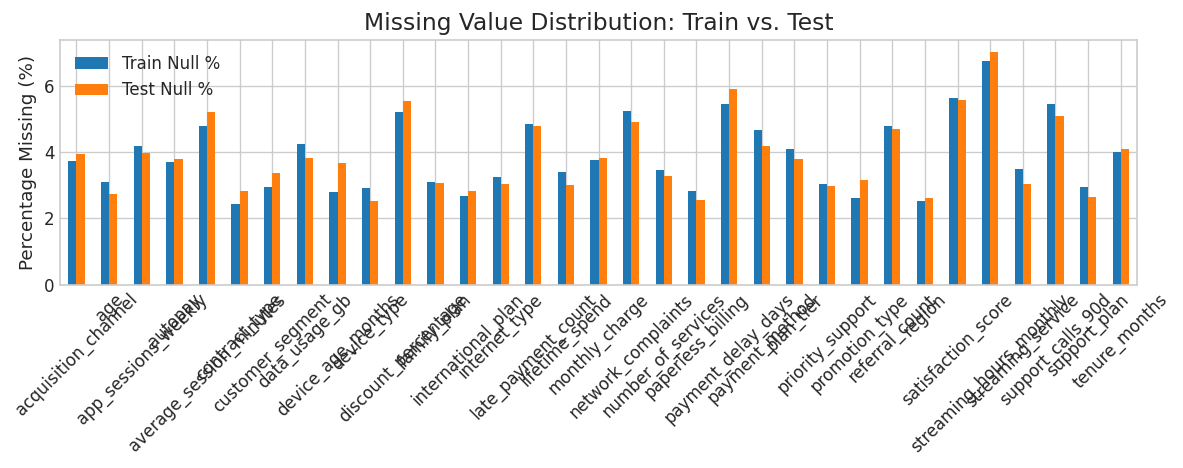

In [13]:
train_missing = train_df.isnull().mean() * 100
test_missing = test_df.isnull().mean() * 100

missing_summary = pd.DataFrame({
    'Train Null %': train_missing,
    'Test Null %': test_missing
}).query('`Train Null %` > 0 or `Test Null %` > 0')

if len(missing_summary) == 0:
    print("Zero missing values detected across train and test sets.")
else:
    print("Missing Value Summary:")
    display(missing_summary)

# Plot top missing columns
    fig, ax = plt.subplots(figsize=(10, 4))
    missing_summary.plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e'])
    plt.title("Missing Value Distribution: Train vs. Test")
    plt.ylabel("Percentage Missing (%)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

##  Target Variable & Class Imbalance Analysis

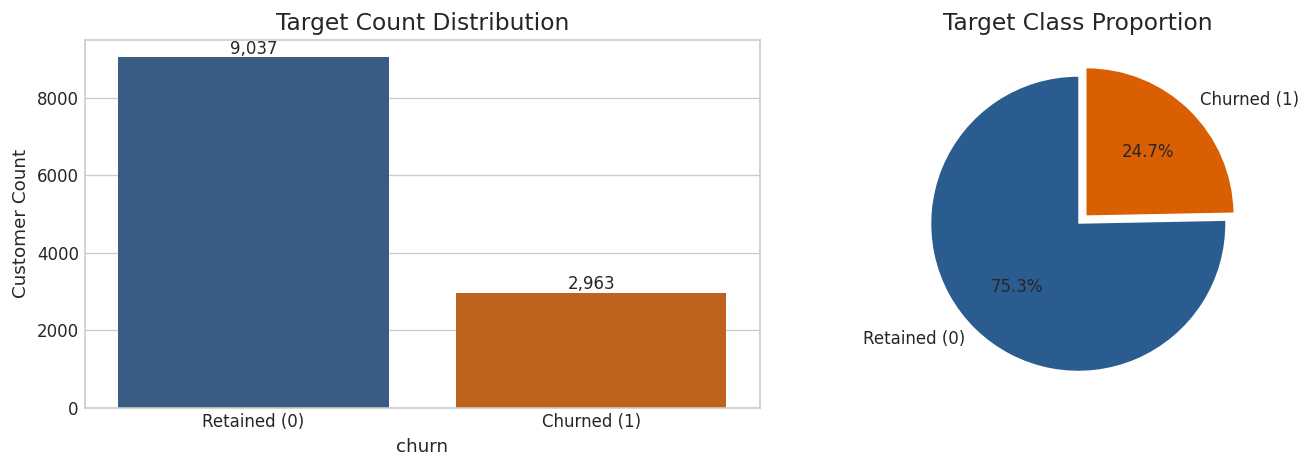

Overall Churn Rate: 24.69% (Retained: 75.31%)


In [15]:
churn_counts = train_df[TARGET_COL].value_counts()
churn_pcts = train_df[TARGET_COL].value_counts(normalize=True) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Bar Plot
sns.barplot(x=churn_counts.index, y=churn_counts.values, ax=ax1, palette=['#2b5c8f', '#d95f02'])
ax1.set_title("Target Count Distribution")
ax1.set_xticklabels(['Retained (0)', 'Churned (1)'])
ax1.set_ylabel("Customer Count")

for p in ax1.patches:
    ax1.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# Donut Chart
ax2.pie(churn_pcts, labels=['Retained (0)', 'Churned (1)'], autopct='%1.1f%%',
        startangle=90, colors=['#2b5c8f', '#d95f02'], explode=(0, 0.08))
ax2.set_title("Target Class Proportion")

plt.tight_layout()
plt.show()

print(f"Overall Churn Rate: {churn_pcts[1]:.2f}% (Retained: {churn_pcts[0]:.2f}%)")

## Univariate Distributions & Skewness Analysis (Numerical Features)

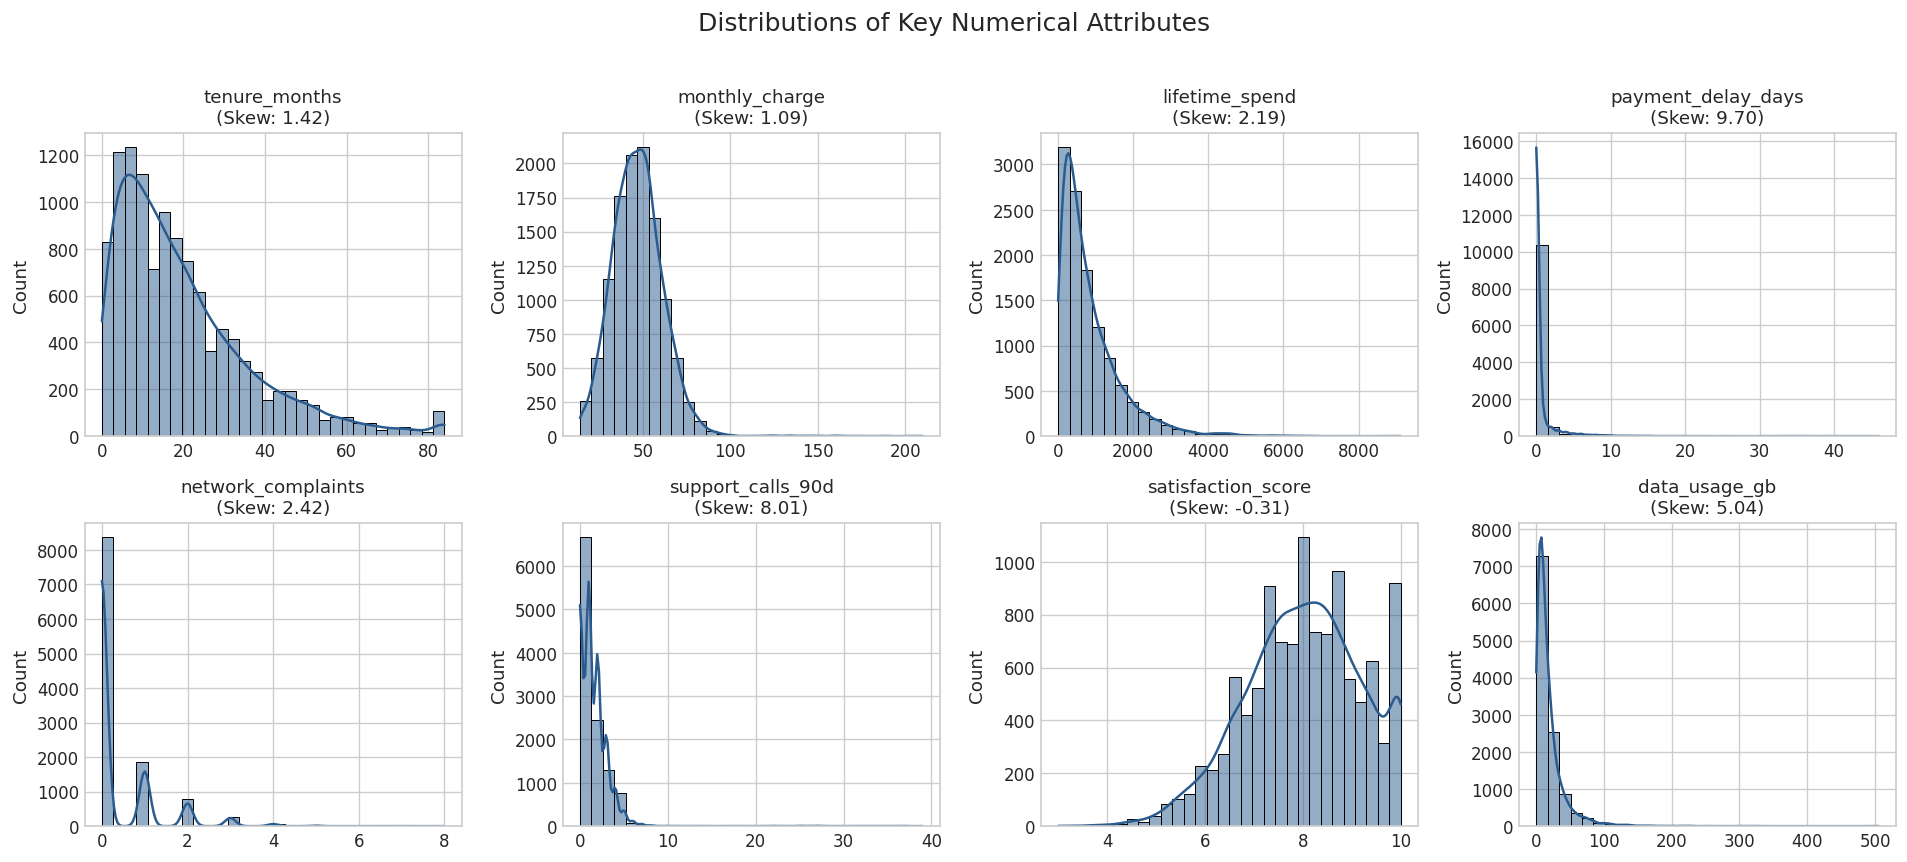

In [16]:
key_numericals = [
    "tenure_months", "monthly_charge", "lifetime_spend",
    "payment_delay_days", "network_complaints", "support_calls_90d",
    "satisfaction_score", "data_usage_gb"
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(key_numericals):
    sns.histplot(train_df[col], kde=True, ax=axes[i], color='#2b5c8f', bins=30)
    skew = train_df[col].skew()
    axes[i].set_title(f"{col}\n(Skew: {skew:.2f})", fontsize=11)
    axes[i].set_xlabel("")

plt.suptitle("Distributions of Key Numerical Attributes", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## Bivariate Analysis — Numerical Features vs. Churn Status

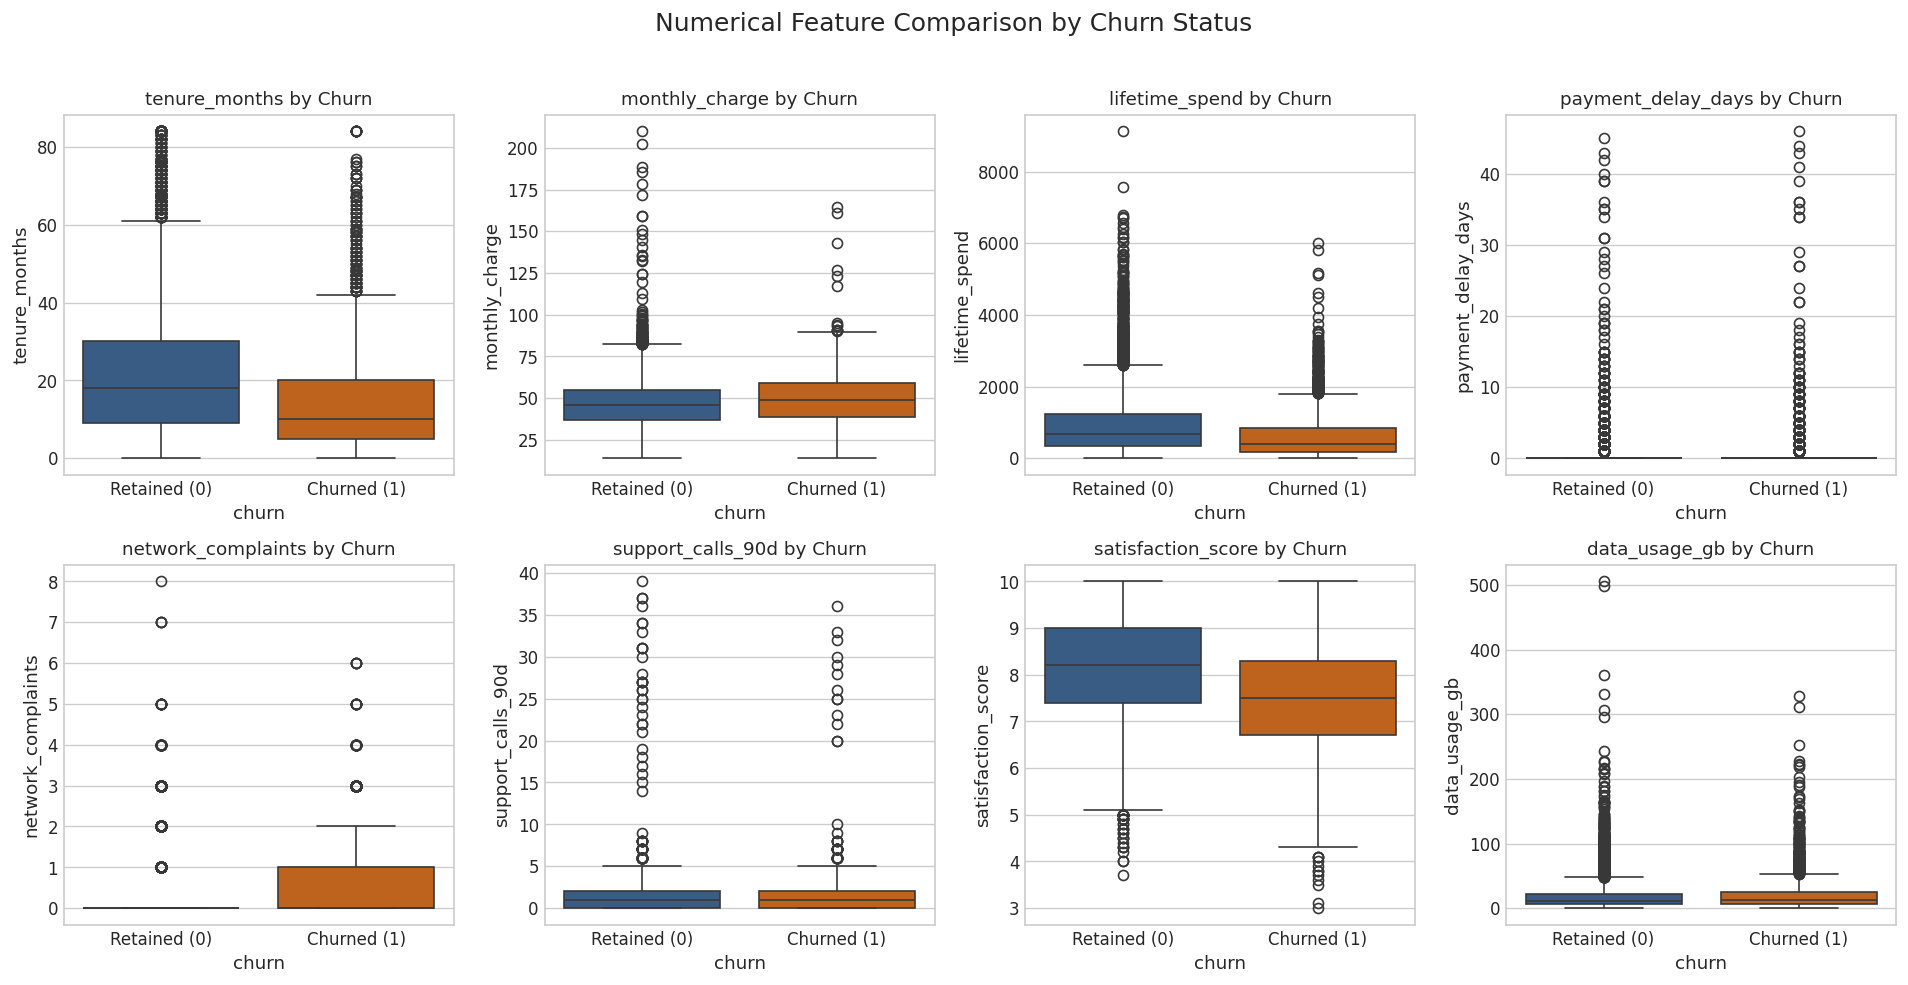

Top Numerical Correlations with Churn:
network_complaints    0.122123
payment_delay_days    0.079324
late_payment_count    0.077612
monthly_charge        0.068917
support_calls_90d     0.053760
dtype: float64

Bottom Numerical Correlations with Churn:
age                   -0.087828
lifetime_spend        -0.156286
discount_percentage   -0.185999
tenure_months         -0.193401
satisfaction_score    -0.259551
dtype: float64


In [17]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(key_numericals):
    sns.boxplot(x=TARGET_COL, y=col, data=train_df, ax=axes[i], palette=['#2b5c8f', '#d95f02'])
    axes[i].set_title(f"{col} by Churn", fontsize=11)
    axes[i].set_xticklabels(['Retained (0)', 'Churned (1)'])

plt.suptitle("Numerical Feature Comparison by Churn Status", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# Point-Biserial Correlations with Target
corrs = train_df[NUMERICAL_COLS].apply(lambda x: x.corr(train_df[TARGET_COL])).sort_values(ascending=False)
print("Top Numerical Correlations with Churn:")
print(corrs.head(5))
print("\nBottom Numerical Correlations with Churn:")
print(corrs.tail(5))

## Bivariate Analysis — Categorical Drivers vs. Churn Rate

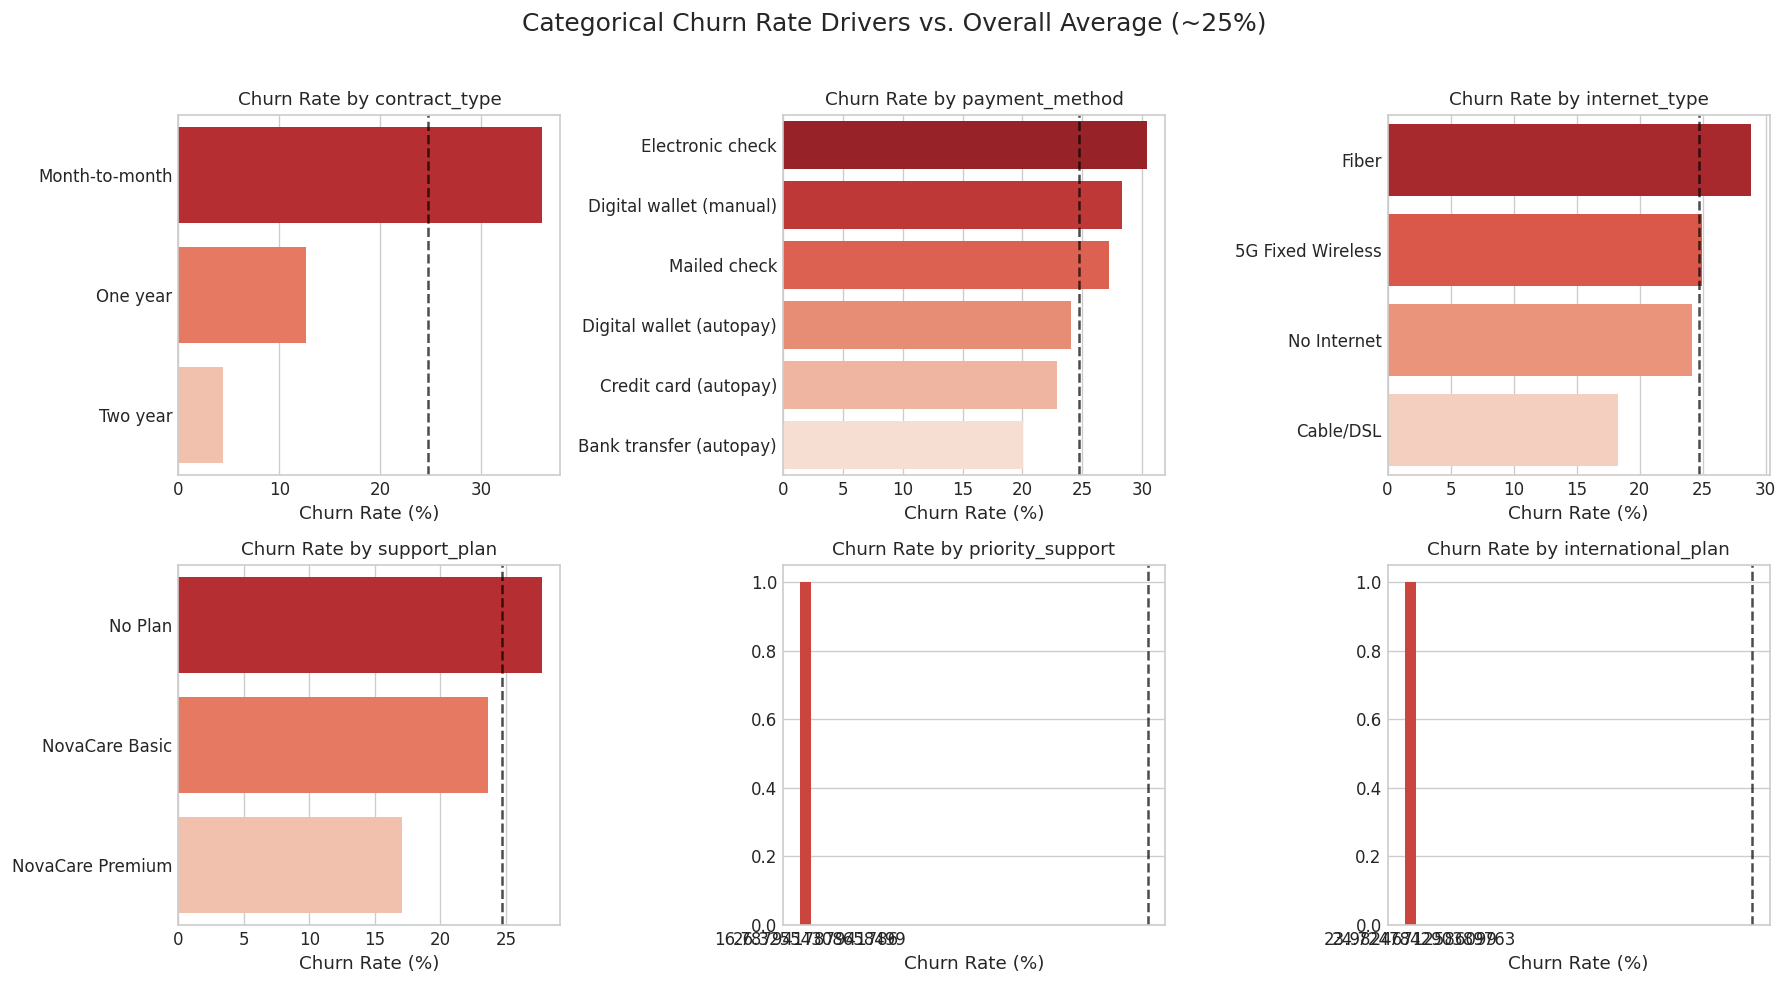

In [18]:
key_categoricals = [
    "contract_type", "payment_method", "internet_type",
    "support_plan", "priority_support", "international_plan"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(key_categoricals):
    # Calculate churn rate per category
    cat_churn = train_df.groupby(col)[TARGET_COL].agg(['mean', 'count']).reset_index()
    cat_churn['mean'] = cat_churn['mean'] * 100
    cat_churn = cat_churn.sort_values(by='mean', ascending=False)

    sns.barplot(x='mean', y=col, data=cat_churn, ax=axes[i], palette='Reds_r')
    axes[i].axvline(churn_pcts[1], color='black', linestyle='--', alpha=0.7, label='Avg Churn Rate')
    axes[i].set_title(f"Churn Rate by {col}", fontsize=11)
    axes[i].set_xlabel("Churn Rate (%)")
    axes[i].set_ylabel("")

plt.suptitle("Categorical Churn Rate Drivers vs. Overall Average (~25%)", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## Correlation Matrix & Multicollinearity Inspection

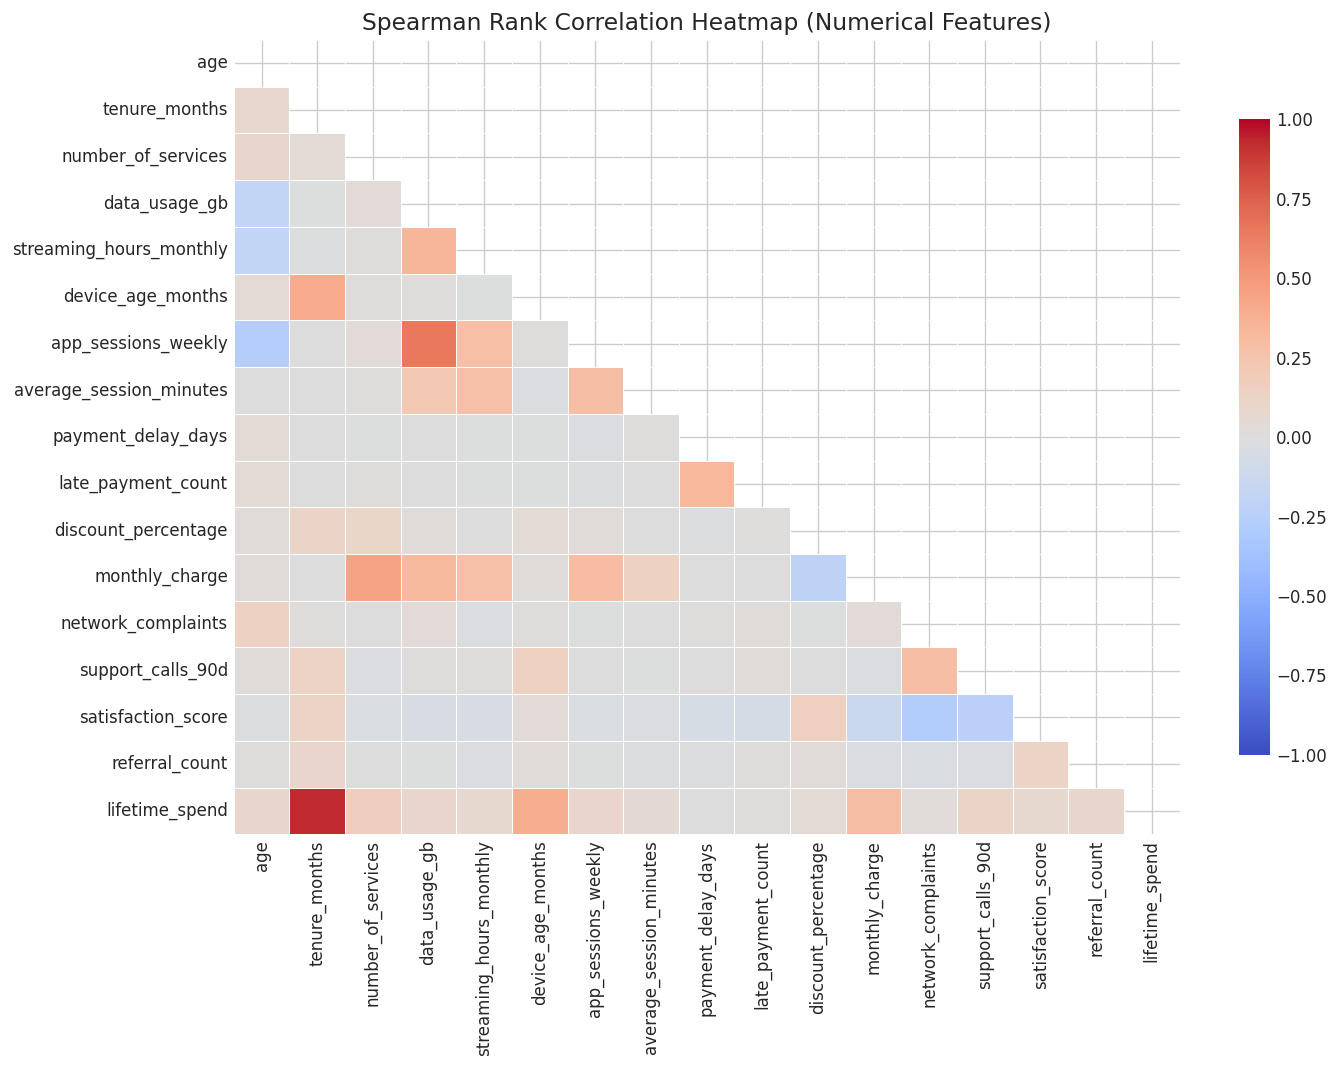

Highly Correlated Feature Pairs (|r| > 0.70):
 - lifetime_spend <-> tenure_months: 0.928


In [19]:
plt.figure(figsize=(12, 9))
corr_matrix = train_df[NUMERICAL_COLS].corr(method='spearman')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', vmin=-1, vmax=1,
            annot=False, linewidths=0.5, cbar_kws={"shrink": 0.8})

plt.title("Spearman Rank Correlation Heatmap (Numerical Features)", fontsize=14)
plt.tight_layout()
plt.show()

# High Correlation Pair Finder (> 0.70)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.70:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            high_corr_pairs.append((col1, col2, corr_matrix.iloc[i, j]))

print("Highly Correlated Feature Pairs (|r| > 0.70):")
for p1, p2, val in high_corr_pairs:
    print(f" - {p1} <-> {p2}: {val:.3f}")

## Multi-Variable Behavioral Interaction Analysis

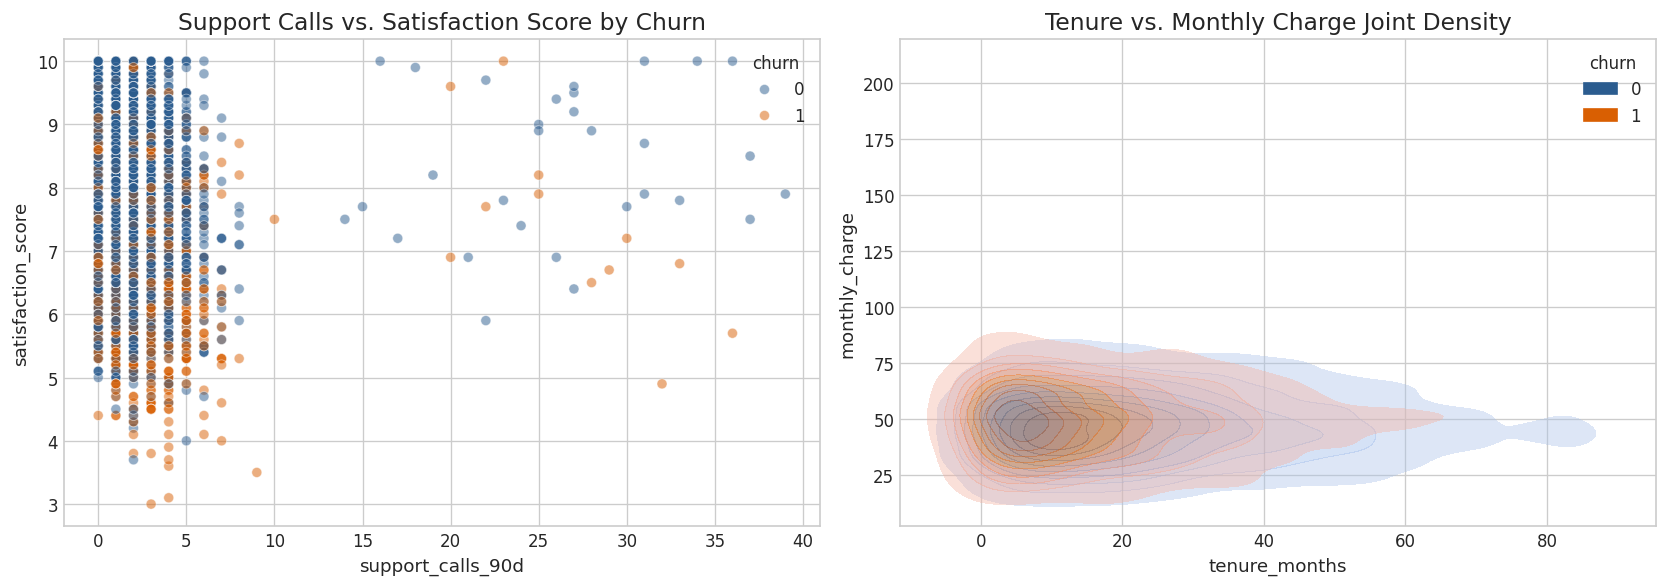

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Interaction 1: Support Calls vs Satisfaction Score by Churn
sns.scatterplot(
    x='support_calls_90d', y='satisfaction_score', hue=TARGET_COL,
    data=train_df, alpha=0.5, palette=['#2b5c8f', '#d95f02'], ax=ax1
)
ax1.set_title("Support Calls vs. Satisfaction Score by Churn")

# Interaction 2: Tenure vs Monthly Charge Density
sns.kdeplot(
    data=train_df, x='tenure_months', y='monthly_charge', hue=TARGET_COL,
    fill=True, common_norm=False, palette=['#2b5c8f', '#d95f02'], alpha=0.4, ax=ax2
)
ax2.set_title("Tenure vs. Monthly Charge Joint Density")

plt.tight_layout()
plt.show()

## Executive Summary of Findings & Feature Engineering Roadmap

In [21]:
summary_text = """
======================================================================
               NOVATEL EDA FINDINGS & FEATURE HYPOTHESES
======================================================================
1. KEY CHURN DRIVERS:
   - High friction indicators (payment_delay_days, support_calls_90d, network_complaints)
     show strong positive correlation with churn.
   - Low tenure_months combined with high monthly_charge represents the highest risk cohort.
   - Month-to-month contracts and paperless billing without autopay exhibit elevated churn rates.

2. CANDIDATE FEATURE FORMULATIONS FOR NOTEBOOK 3:
   - Effective Cost Ratio: monthly_charge * (1 - discount_percentage / 100)
   - Lifetime Monthly Avg: lifetime_spend / (tenure_months + 1)
   - Friction Severity Index: (network_complaints * 2) + support_calls_90d + payment_delay_days
   - App Intensity: app_sessions_weekly * average_session_minutes
   - Relative Spend Delta: monthly_charge - (mean monthly_charge by plan_tier)

3. PREPROCESSING RULES:
   - Apply Log Transformations (np.log1p) to right-skewed lifetime_spend & payment_delay_days.
   - Out-of-fold target encoding for high-cardinality categoricals (acquisition_channel, region).
======================================================================
"""

print(summary_text)


               NOVATEL EDA FINDINGS & FEATURE HYPOTHESES
1. KEY CHURN DRIVERS:
   - High friction indicators (payment_delay_days, support_calls_90d, network_complaints)
     show strong positive correlation with churn.
   - Low tenure_months combined with high monthly_charge represents the highest risk cohort.
   - Month-to-month contracts and paperless billing without autopay exhibit elevated churn rates.

2. CANDIDATE FEATURE FORMULATIONS FOR NOTEBOOK 3:
   - Effective Cost Ratio: monthly_charge * (1 - discount_percentage / 100)
   - Lifetime Monthly Avg: lifetime_spend / (tenure_months + 1)
   - Friction Severity Index: (network_complaints * 2) + support_calls_90d + payment_delay_days
   - App Intensity: app_sessions_weekly * average_session_minutes
   - Relative Spend Delta: monthly_charge - (mean monthly_charge by plan_tier)

3. PREPROCESSING RULES:
   - Apply Log Transformations (np.log1p) to right-skewed lifetime_spend & payment_delay_days.
   - Out-of-fold target encoding for 